In [3]:
import pandas as pd

years = range(2015, 2026)

dfs = []

for year in years:
    url = (
        "https://github.com/nflverse/nflverse-data/"
        f"releases/download/stats_team/stats_team_week_{year}.csv"
    )

    df = pd.read_csv(url)
    dfs.append(df)

team_stats = pd.concat(dfs, ignore_index=True)

print(team_stats.head())
print("\nNumber of rows:", len(team_stats))
print("\nColumns:")
print(team_stats.columns.tolist())

   season  week team season_type          game_id opponent_team  completions  \
0    2015     1  ARI         REG   2015_01_NO_ARI            NO           19   
1    2015     1  ATL         REG  2015_01_PHI_ATL           PHI           23   
2    2015     1  BAL         REG  2015_01_BAL_DEN           DEN           18   
3    2015     1  BUF         REG  2015_01_IND_BUF           IND           14   
4    2015     1  CAR         REG  2015_01_CAR_JAX           JAX           18   

   attempts  passing_yards  passing_tds  ...  pt_yards  pt_inside_20  \
0        32            307            3  ...       158             2   
1        34            298            2  ...       231             3   
2        32            117            0  ...       310             2   
3        19            195            1  ...       252             2   
4        31            175            1  ...       179             2   

   pt_out_of_bounds  pt_downed  pt_touchback  pt_fair_caught  pt_returned  \
0        

In [4]:
# Find the columns that are useful for our project

keywords = [
    "passing",
    "rushing",
    "turnover",
    "fumble",
    "yards",
    "points"
]

for column in team_stats.columns:
    if any(word in column.lower() for word in keywords):
        print(column)

passing_yards
passing_tds
passing_interceptions
sack_yards_lost
sack_fumbles
sack_fumbles_lost
passing_air_yards
passing_yards_after_catch
passing_first_downs
passing_epa
passing_cpoe
passing_2pt_conversions
passing_10
passing_16
passing_20
passing_40
rushing_yards
rushing_tds
rushing_fumbles
rushing_fumbles_lost
rushing_first_downs
rushing_epa
rushing_2pt_conversions
rushing_10
rushing_12
rushing_20
rushing_40
receiving_yards
receiving_fumbles
receiving_fumbles_lost
receiving_air_yards
receiving_yards_after_catch
def_tackles_for_loss_yards
def_fumbles_forced
def_sack_yards
def_interception_yards
def_fumbles
misc_yards
fumble_recovery_own
fumble_recovery_yards_own
fumble_recovery_opp
fumble_recovery_yards_opp
fumble_recovery_tds
penalty_yards
fumbles_forced_by_opp
fumbles_not_forced
fumbles_out_of_bounds
fumbles_total
fumbles_lost_total
punt_return_yards
kickoff_return_yards
pt_yards
pt_return_yards
pt_net_yards


In [5]:
# Select the variables we want to use

nfl_data = team_stats[[
    "season",
    "week",
    "team",
    "opponent_team",
    "game_id",
    "passing_yards",
    "rushing_yards",
    "passing_interceptions",
    "rushing_fumbles_lost"
]].copy()

print(nfl_data.head())

print("\nNumber of rows:", len(nfl_data))
print("Number of columns:", len(nfl_data.columns))

   season  week team opponent_team          game_id  passing_yards  \
0    2015     1  ARI            NO   2015_01_NO_ARI            307   
1    2015     1  ATL           PHI  2015_01_PHI_ATL            298   
2    2015     1  BAL           DEN  2015_01_BAL_DEN            117   
3    2015     1  BUF           IND  2015_01_IND_BUF            195   
4    2015     1  CAR           JAX  2015_01_CAR_JAX            175   

   rushing_yards  passing_interceptions  rushing_fumbles_lost  
0            120                      0                     1  
1            105                      2                     0  
2             73                      2                     0  
3            147                      0                     0  
4            105                      1                     0  

Number of rows: 6056
Number of columns: 9


In [6]:
nfl_data["total_yards"] = (
    nfl_data["passing_yards"] +
    nfl_data["rushing_yards"]
)

print(nfl_data[[
    "team",
    "passing_yards",
    "rushing_yards",
    "total_yards"
]].head())

  team  passing_yards  rushing_yards  total_yards
0  ARI            307            120          427
1  ATL            298            105          403
2  BAL            117             73          190
3  BUF            195            147          342
4  CAR            175            105          280


In [1]:
import pandas as pd

games = pd.read_csv("games.csv")

print(games.head())

           game_id  season game_type  week     gameday weekday gametime  \
0  1999_01_MIN_ATL    1999       REG     1  1999-09-12  Sunday      NaN   
1   1999_01_KC_CHI    1999       REG     1  1999-09-12  Sunday      NaN   
2  1999_01_PIT_CLE    1999       REG     1  1999-09-12  Sunday      NaN   
3   1999_01_OAK_GB    1999       REG     1  1999-09-12  Sunday      NaN   
4  1999_01_BUF_IND    1999       REG     1  1999-09-12  Sunday      NaN   

  away_team  away_score home_team  ...  wind  away_qb_id  home_qb_id  \
0       MIN        17.0       ATL  ...   NaN  00-0003761  00-0002876   
1        KC        17.0       CHI  ...  12.0  00-0006300  00-0010560   
2       PIT        43.0       CLE  ...  12.0  00-0015700  00-0004230   
3       OAK        24.0        GB  ...  10.0  00-0005741  00-0005106   
4       BUF        14.0       IND  ...   NaN  00-0005363  00-0010346   

         away_qb_name    home_qb_name          away_coach    home_coach  \
0  Randall Cunningham  Chris Chandler    

In [2]:
import pandas as pd

# Load games
games = pd.read_csv("games.csv")

# Only use 2015-2025 regular season games
games = games[
    (games["season"] >= 2015) &
    (games["season"] <= 2025) &
    (games["game_type"] == "REG")
].copy()

print(games.head())

              game_id  season game_type  week     gameday   weekday gametime  \
4248   2015_01_PIT_NE    2015       REG     1  2015-09-10  Thursday    20:30   
4249  2015_01_IND_BUF    2015       REG     1  2015-09-13    Sunday    13:00   
4250   2015_01_GB_CHI    2015       REG     1  2015-09-13    Sunday    13:00   
4251   2015_01_KC_HOU    2015       REG     1  2015-09-13    Sunday    13:00   
4252  2015_01_CAR_JAX    2015       REG     1  2015-09-13    Sunday    13:00   

     away_team  away_score home_team  ...  wind  away_qb_id  home_qb_id  \
4248       PIT        21.0        NE  ...   7.0  00-0022924  00-0019596   
4249       IND        14.0       BUF  ...  15.0  00-0029668  00-0028118   
4250        GB        31.0       CHI  ...  11.0  00-0023459  00-0024226   
4251        KC        27.0       HOU  ...   NaN  00-0023436  00-0026625   
4252       CAR        20.0       JAX  ...   7.0  00-0027939  00-0031407   

            away_qb_name   home_qb_name     away_coach      home_coa

In [3]:
years = range(2015, 2026)

dfs = []

for year in years:
    url = (
        "https://github.com/nflverse/nflverse-data/"
        f"releases/download/stats_team/stats_team_week_{year}.csv"
    )

    df = pd.read_csv(url)
    dfs.append(df)

team_stats = pd.concat(dfs, ignore_index=True)

print(team_stats.head())

   season  week team season_type          game_id opponent_team  completions  \
0    2015     1  ARI         REG   2015_01_NO_ARI            NO           19   
1    2015     1  ATL         REG  2015_01_PHI_ATL           PHI           23   
2    2015     1  BAL         REG  2015_01_BAL_DEN           DEN           18   
3    2015     1  BUF         REG  2015_01_IND_BUF           IND           14   
4    2015     1  CAR         REG  2015_01_CAR_JAX           JAX           18   

   attempts  passing_yards  passing_tds  ...  pt_yards  pt_inside_20  \
0        32            307            3  ...       158             2   
1        34            298            2  ...       231             3   
2        32            117            0  ...       310             2   
3        19            195            1  ...       252             2   
4        31            175            1  ...       179             2   

   pt_out_of_bounds  pt_downed  pt_touchback  pt_fair_caught  pt_returned  \
0        

In [4]:
nfl_data = team_stats[[
    "season",
    "week",
    "team",
    "opponent_team",
    "game_id",
    "passing_yards",
    "rushing_yards",
    "passing_interceptions",
    "rushing_fumbles_lost"
]].copy()

nfl_data["total_yards"] = (
    nfl_data["passing_yards"] +
    nfl_data["rushing_yards"]
)

print(nfl_data.head())

   season  week team opponent_team          game_id  passing_yards  \
0    2015     1  ARI            NO   2015_01_NO_ARI            307   
1    2015     1  ATL           PHI  2015_01_PHI_ATL            298   
2    2015     1  BAL           DEN  2015_01_BAL_DEN            117   
3    2015     1  BUF           IND  2015_01_IND_BUF            195   
4    2015     1  CAR           JAX  2015_01_CAR_JAX            175   

   rushing_yards  passing_interceptions  rushing_fumbles_lost  total_yards  
0            120                      0                     1          427  
1            105                      2                     0          403  
2             73                      2                     0          190  
3            147                      0                     0          342  
4            105                      1                     0          280  


In [5]:
home = games[[
    "game_id",
    "season",
    "week",
    "home_team",
    "away_team",
    "home_score",
    "away_score"
]].copy()

home = home.rename(columns={
    "home_team": "team",
    "away_team": "opponent_team",
    "home_score": "points_scored",
    "away_score": "points_allowed"
})

# 1 means the team was at home
home["home"] = 1

# 1 = win, 0 = loss
home["win"] = (
    home["points_scored"] > home["points_allowed"]
).astype(int)

print(home.head())

              game_id  season  week team opponent_team  points_scored  \
4248   2015_01_PIT_NE    2015     1   NE           PIT           28.0   
4249  2015_01_IND_BUF    2015     1  BUF           IND           27.0   
4250   2015_01_GB_CHI    2015     1  CHI            GB           23.0   
4251   2015_01_KC_HOU    2015     1  HOU            KC           20.0   
4252  2015_01_CAR_JAX    2015     1  JAX           CAR            9.0   

      points_allowed  home  win  
4248            21.0     1    1  
4249            14.0     1    1  
4250            31.0     1    0  
4251            27.0     1    0  
4252            20.0     1    0  


In [6]:
away = games[[
    "game_id",
    "season",
    "week",
    "home_team",
    "away_team",
    "home_score",
    "away_score"
]].copy()

away = away.rename(columns={
    "away_team": "team",
    "home_team": "opponent_team",
    "away_score": "points_scored",
    "home_score": "points_allowed"
})

# 0 means the team was away
away["home"] = 0

# 1 = win, 0 = loss
away["win"] = (
    away["points_scored"] > away["points_allowed"]
).astype(int)

print(away.head())

              game_id  season  week opponent_team team  points_allowed  \
4248   2015_01_PIT_NE    2015     1            NE  PIT            28.0   
4249  2015_01_IND_BUF    2015     1           BUF  IND            27.0   
4250   2015_01_GB_CHI    2015     1           CHI   GB            23.0   
4251   2015_01_KC_HOU    2015     1           HOU   KC            20.0   
4252  2015_01_CAR_JAX    2015     1           JAX  CAR             9.0   

      points_scored  home  win  
4248           21.0     0    0  
4249           14.0     0    0  
4250           31.0     0    1  
4251           27.0     0    1  
4252           20.0     0    1  


In [7]:
game_results = pd.concat(
    [home, away],
    ignore_index=True
)

game_results = game_results.sort_values(
    ["season", "week", "game_id", "home"],
    ascending=[True, True, True, False]
)

print(game_results.head(10))
print("\nNumber of rows:", len(game_results))

              game_id  season  week team opponent_team  points_scored  \
10    2015_01_BAL_DEN    2015     1  DEN           BAL           19.0   
2905  2015_01_BAL_DEN    2015     1  BAL           DEN           13.0   
4     2015_01_CAR_JAX    2015     1  JAX           CAR            9.0   
2899  2015_01_CAR_JAX    2015     1  CAR           JAX           20.0   
11    2015_01_CIN_OAK    2015     1  OAK           CIN           13.0   
2906  2015_01_CIN_OAK    2015     1  CIN           OAK           33.0   
5     2015_01_CLE_NYJ    2015     1  NYJ           CLE           31.0   
2900  2015_01_CLE_NYJ    2015     1  CLE           NYJ           10.0   
9      2015_01_DET_SD    2015     1   SD           DET           33.0   
2904   2015_01_DET_SD    2015     1  DET            SD           28.0   

      points_allowed  home  win  
10              13.0     1    1  
2905            19.0     0    0  
4               20.0     1    0  
2899             9.0     0    1  
11              33.0     1

In [8]:
merged_data = pd.merge(
    nfl_data,
    game_results,
    on=[
        "game_id",
        "season",
        "week",
        "team",
        "opponent_team"
    ],
    how="inner"
)

print(merged_data.head())

print("\nNumber of rows:", len(merged_data))

print("\nColumns:")
print(merged_data.columns.tolist())

   season  week team opponent_team          game_id  passing_yards  \
0    2015     1  ARI            NO   2015_01_NO_ARI            307   
1    2015     1  ATL           PHI  2015_01_PHI_ATL            298   
2    2015     1  BAL           DEN  2015_01_BAL_DEN            117   
3    2015     1  BUF           IND  2015_01_IND_BUF            195   
4    2015     1  CAR           JAX  2015_01_CAR_JAX            175   

   rushing_yards  passing_interceptions  rushing_fumbles_lost  total_yards  \
0            120                      0                     1          427   
1            105                      2                     0          403   
2             73                      2                     0          190   
3            147                      0                     0          342   
4            105                      1                     0          280   

   points_scored  points_allowed  home  win  
0           31.0            19.0     1    1  
1           26.0  

In [9]:
merged_data = merged_data.sort_values(
    ["team", "season", "week"]
).copy()

merged_data["avg_passing_yards"] = (
    merged_data.groupby(["team", "season"])["passing_yards"]
    .transform(lambda x: x.shift(1).expanding().mean())
)

merged_data["avg_rushing_yards"] = (
    merged_data.groupby(["team", "season"])["rushing_yards"]
    .transform(lambda x: x.shift(1).expanding().mean())
)

merged_data["avg_total_yards"] = (
    merged_data.groupby(["team", "season"])["total_yards"]
    .transform(lambda x: x.shift(1).expanding().mean())
)

merged_data["avg_points_scored"] = (
    merged_data.groupby(["team", "season"])["points_scored"]
    .transform(lambda x: x.shift(1).expanding().mean())
)

merged_data["avg_points_allowed"] = (
    merged_data.groupby(["team", "season"])["points_allowed"]
    .transform(lambda x: x.shift(1).expanding().mean())
)

print(merged_data[[
    "season",
    "week",
    "team",
    "avg_passing_yards",
    "avg_rushing_yards",
    "avg_total_yards",
    "avg_points_scored",
    "avg_points_allowed",
    "home",
    "win"
]].head(20))

     season  week team  avg_passing_yards  avg_rushing_yards  avg_total_yards  \
0      2015     1  ARI                NaN                NaN              NaN   
26     2015     2  ARI         307.000000         120.000000       427.000000   
52     2015     3  ARI         246.000000         117.500000       363.500000   
102    2015     5  ARI         267.666667         124.666667       392.333333   
124    2015     6  ARI         243.500000         140.250000       383.750000   
150    2015     7  ARI         279.000000         123.200000       402.200000   
174    2015     8  ARI         278.333333         127.666667       406.000000   
216    2015    10  ARI         292.000000         126.428571       418.428571   
240    2015    11  ARI         300.875000         125.250000       426.125000   
262    2015    12  ARI         302.666667         120.444444       423.111111   
314    2015    14  ARI         299.500000         115.400000       414.900000   
340    2015    15  ARI      

In [11]:

merged_data["pregame_win_pct"] = (
    merged_data.groupby(["team", "season"])["win"]
    .transform(lambda x: x.shift(1).expanding().mean())
)

print(merged_data[[
    "season",
    "week",
    "team",
    "pregame_win_pct",
    "win"
]].head(20))

     season  week team  pregame_win_pct  win
0      2015     1  ARI              NaN    1
26     2015     2  ARI         1.000000    1
52     2015     3  ARI         1.000000    1
102    2015     5  ARI         1.000000    1
124    2015     6  ARI         1.000000    0
150    2015     7  ARI         0.800000    1
174    2015     8  ARI         0.833333    1
216    2015    10  ARI         0.857143    1
240    2015    11  ARI         0.875000    1
262    2015    12  ARI         0.888889    1
314    2015    14  ARI         0.900000    1
340    2015    15  ARI         0.909091    1
366    2015    16  ARI         0.916667    1
394    2015    17  ARI         0.923077    0
420    2016     1  ARI              NaN    0
448    2016     2  ARI         0.000000    1
476    2016     3  ARI         0.500000    0
504    2016     4  ARI         0.333333    0
530    2016     5  ARI         0.250000    1
556    2016     6  ARI         0.400000    1


In [12]:
merged_data["turnovers"] = (
    merged_data["passing_interceptions"] +
    merged_data["rushing_fumbles_lost"]
)

In [13]:
merged_data["avg_turnovers"] = (
    merged_data.groupby(["team", "season"])["turnovers"]
    .transform(lambda x: x.shift(1).expanding().mean())
)

In [14]:
print(merged_data[[
    "season",
    "week",
    "team",
    "turnovers",
    "avg_turnovers"
]].head(20))

     season  week team  turnovers  avg_turnovers
0      2015     1  ARI          1            NaN
26     2015     2  ARI          1       1.000000
52     2015     3  ARI          1       1.000000
102    2015     5  ARI          0       1.000000
124    2015     6  ARI          2       0.750000
150    2015     7  ARI          0       1.000000
174    2015     8  ARI          3       0.833333
216    2015    10  ARI          1       1.142857
240    2015    11  ARI          2       1.125000
262    2015    12  ARI          0       1.222222
314    2015    14  ARI          0       1.100000
340    2015    15  ARI          0       1.000000
366    2015    16  ARI          2       0.916667
394    2015    17  ARI          3       1.000000
420    2016     1  ARI          0            NaN
448    2016     2  ARI          0       0.000000
476    2016     3  ARI          5       0.000000
504    2016     4  ARI          4       1.666667
530    2016     5  ARI          0       2.250000
556    2016     6  A

In [15]:
model_data = merged_data[[
    "season",
    "week",
    "team",
    "opponent_team",
    "avg_points_scored",
    "avg_points_allowed",
    "avg_passing_yards",
    "avg_rushing_yards",
    "avg_total_yards",
    "avg_turnovers",
    "pregame_win_pct",
    "home",
    "win"
]].copy()

print(model_data.head(20))

     season  week team opponent_team  avg_points_scored  avg_points_allowed  \
0      2015     1  ARI            NO                NaN                 NaN   
26     2015     2  ARI           CHI          31.000000           19.000000   
52     2015     3  ARI            SF          39.500000           21.000000   
102    2015     5  ARI           DET          42.000000           16.333333   
124    2015     6  ARI           PIT          42.000000           16.500000   
150    2015     7  ARI           BAL          36.200000           18.200000   
174    2015     8  ARI           CLE          34.500000           18.166667   
216    2015    10  ARI           SEA          34.428571           18.428571   
240    2015    11  ARI           CIN          35.000000           20.125000   
262    2015    12  ARI            SF          34.888889           21.333333   
314    2015    14  ARI           MIN          33.300000           20.500000   
340    2015    15  ARI           PHI          32.363

In [16]:
model_data = model_data.dropna()

print(model_data.head())

print("\nNumber of rows:", len(model_data))
print("Number of columns:", len(model_data.columns))

print("\nMissing values:")
print(model_data.isnull().sum())

     season  week team opponent_team  avg_points_scored  avg_points_allowed  \
26     2015     2  ARI           CHI               31.0           19.000000   
52     2015     3  ARI            SF               39.5           21.000000   
102    2015     5  ARI           DET               42.0           16.333333   
124    2015     6  ARI           PIT               42.0           16.500000   
150    2015     7  ARI           BAL               36.2           18.200000   

     avg_passing_yards  avg_rushing_yards  avg_total_yards  avg_turnovers  \
26          307.000000         120.000000       427.000000           1.00   
52          246.000000         117.500000       363.500000           1.00   
102         267.666667         124.666667       392.333333           1.00   
124         243.500000         140.250000       383.750000           0.75   
150         279.000000         123.200000       402.200000           1.00   

     pregame_win_pct  home  win  
26               1.0     0  

In [17]:
features = [
    "avg_points_scored",
    "avg_points_allowed",
    "avg_passing_yards",
    "avg_rushing_yards",
    "avg_total_yards",
    "avg_turnovers",
    "pregame_win_pct",
    "home"
]

X = model_data[features]
y = model_data["win"]

print(X.head())
print(y.head())

     avg_points_scored  avg_points_allowed  avg_passing_yards  \
26                31.0           19.000000         307.000000   
52                39.5           21.000000         246.000000   
102               42.0           16.333333         267.666667   
124               42.0           16.500000         243.500000   
150               36.2           18.200000         279.000000   

     avg_rushing_yards  avg_total_yards  avg_turnovers  pregame_win_pct  home  
26          120.000000       427.000000           1.00              1.0     0  
52          117.500000       363.500000           1.00              1.0     1  
102         124.666667       392.333333           1.00              1.0     0  
124         140.250000       383.750000           0.75              1.0     0  
150         123.200000       402.200000           1.00              0.8     1  
26     1
52     1
102    1
124    0
150    1
Name: win, dtype: int64


In [18]:
train = model_data[model_data["season"] <= 2023]
test = model_data[model_data["season"] >= 2024]

X_train = train[features]
y_train = train["win"]

X_test = test[features]
y_test = test["win"]

print("Training games:", len(X_train))
print("Testing games:", len(X_test))

Training games: 4174
Testing games: 1024


In [27]:
print(model_data[[
    "avg_points_scored",
    "avg_points_allowed",
    "avg_passing_yards",
    "avg_rushing_yards",
    "avg_total_yards",
    "avg_turnovers",
    "pregame_win_pct",
    "home",
    "win"
]].describe())

       avg_points_scored  avg_points_allowed  avg_passing_yards  \
count        5198.000000         5198.000000        5198.000000   
mean           22.792256           22.781287         247.101306   
std             5.531477            5.021006          42.737785   
min             0.000000            0.000000          82.000000   
25%            19.114583           19.714286         218.625000   
50%            22.636364           22.777778         246.258333   
75%            26.250000           25.750000         273.333333   
max            59.000000           59.000000         466.000000   

       avg_rushing_yards  avg_total_yards  avg_turnovers  pregame_win_pct  \
count        5198.000000      5198.000000    5198.000000      5198.000000   
mean          112.782419       359.883725       0.955046         0.496841   
std            27.362001        45.647575       0.481961         0.265346   
min            21.000000       157.000000       0.000000         0.000000   
25%        

In [28]:
print(model_data["win"].value_counts())

print("\nPercentages:")
print(model_data["win"].value_counts(normalize=True) * 100)

win
0    2606
1    2592
Name: count, dtype: int64

Percentages:
win
0    50.134667
1    49.865333
Name: proportion, dtype: float64


In [19]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

log_predictions = log_model.predict(X_test)

print(log_predictions[:20])

[0 1 1 0 0 0 0 1 1 0 0 1 1 0 0 1 1 1 1 1]


In [20]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

log_accuracy = accuracy_score(y_test, log_predictions)

print("Logistic Regression Accuracy:")
print(log_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, log_predictions))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, log_predictions))

Logistic Regression Accuracy:
0.5849609375

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.64      0.61       513
           1       0.59      0.53      0.56       511

    accuracy                           0.58      1024
   macro avg       0.59      0.58      0.58      1024
weighted avg       0.59      0.58      0.58      1024


Confusion Matrix:
[[327 186]
 [239 272]]


In [21]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

print(rf_predictions[:20])

[0 1 0 0 0 0 0 0 1 0 0 1 1 0 0 1 0 0 1 1]


In [22]:
rf_accuracy = accuracy_score(y_test, rf_predictions)

print("Random Forest Accuracy:")
print(rf_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, rf_predictions))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_predictions))

Random Forest Accuracy:
0.55859375

Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.64      0.59       513
           1       0.57      0.48      0.52       511

    accuracy                           0.56      1024
   macro avg       0.56      0.56      0.56      1024
weighted avg       0.56      0.56      0.56      1024


Confusion Matrix:
[[329 184]
 [268 243]]


In [23]:
print("Model Comparison")
print("------------------")
print("Logistic Regression:", round(log_accuracy * 100, 2), "%")
print("Random Forest:", round(rf_accuracy * 100, 2), "%")

Model Comparison
------------------
Logistic Regression: 58.5 %
Random Forest: 55.86 %


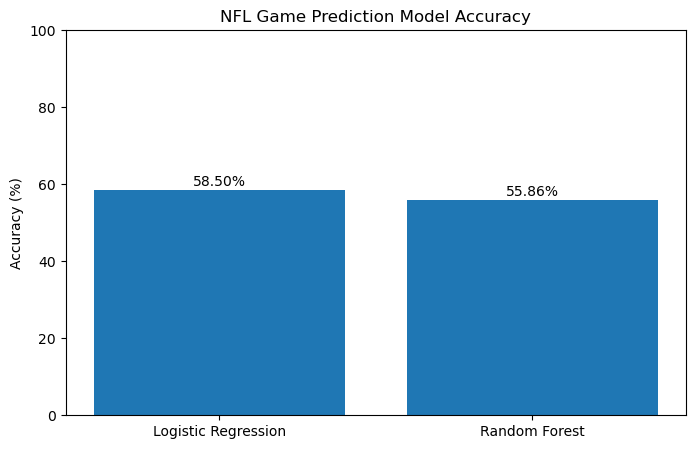

In [24]:
import matplotlib.pyplot as plt

models = ["Logistic Regression", "Random Forest"]
accuracies = [log_accuracy * 100, rf_accuracy * 100]

plt.figure(figsize=(8, 5))

bars = plt.bar(models, accuracies)

plt.ylabel("Accuracy (%)")
plt.title("NFL Game Prediction Model Accuracy")
plt.ylim(0, 100)

for bar, accuracy in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{accuracy:.2f}%",
        ha="center"
    )

plt.show()

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=True
)

print(feature_importance)

              Feature  Importance
7                home    0.021451
6     pregame_win_pct    0.106780
5       avg_turnovers    0.118276
3   avg_rushing_yards    0.146619
2   avg_passing_yards    0.147791
1  avg_points_allowed    0.151552
4     avg_total_yards    0.152316
0   avg_points_scored    0.155215


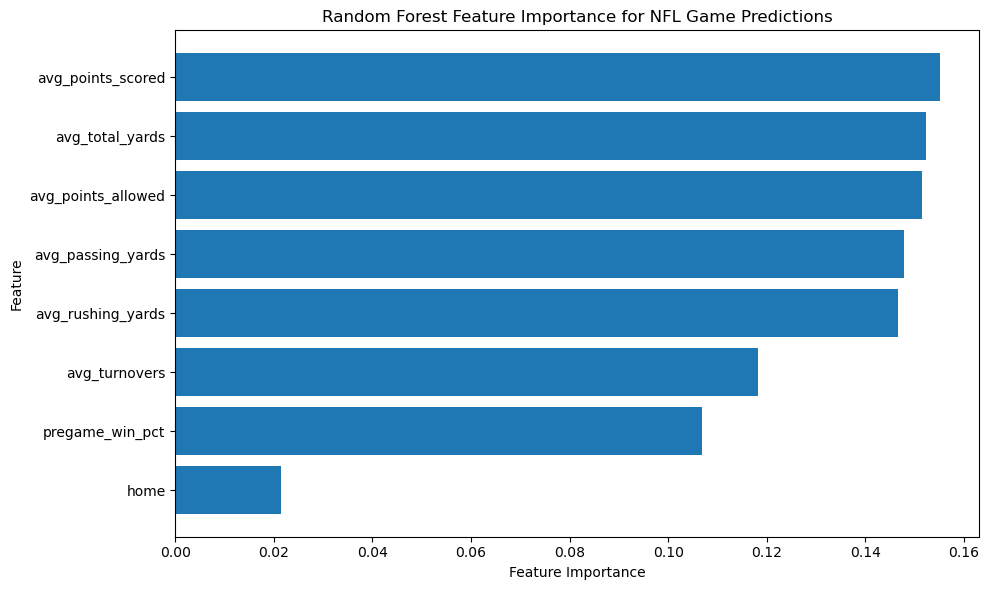

In [26]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance for NFL Game Predictions")

plt.tight_layout()
plt.show()

 The feature importance graph shows which variables the Random Forest model relied on most when predicting NFL game outcomes. Average points scored, total yards, and points allowed were among the most important features, while whether a team was playing at home had much lower importance.